# CONTROL SAMPLES (LABORATORY CONTROL SAMPLES, LCS) 

Control samples verify method accuracy and stability using a clean, well-defined matrix with 
known analyte concentrations. 

**Data Characteristics**
- Known target value (mean) 
- Acceptable tolerance window 
- Long time-series per analyte and method 

**Typical Anomaly Patterns** 
- Mean shift: systematic bias developing over time 
- Variance inflation: increasing noise before failure 
- Step change: abrupt change after maintenance, calibration, or reagent replacement 

**Interpretation** 
LCS anomalies often indicate: 
- Calibration errors 
- Instrument drift 
- Reagent degradation 

For modeling, LCS data is well-suited to: 
- Time-series change detection 
- Distributional shift detection 
- Trend and drift analysis


## Data settings control samples


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [4]:
df = pd.read_csv("Data/ResultSet.csv")
print(f"Raw shape: {df.shape}")
display(df)

# Control samples in this dataset are represented by ANALYTICAL_TYPE == 'Standard'.
CONTROL_ANALYTICAL_TYPE = "Standard"

Raw shape: (99999, 27)


,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,INTERNAL_MAX_INCLUSIVE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,26.110560,34.689440,Y,Y,33.120800,27.679200,Y,Y,10,1.250,15.0,1.250,30.40,NaN,MG_KG,OREAS_905,NaN
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,26.110560,34.689440,Y,Y,33.120800,27.679200,Y,Y,10,1.250,15.0,1.250,30.40,NaN,MG_KG,OREAS_905,NaN
2,Replicate,Sample,Sample,TSV_LB0016663011,1492.268392,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,NaN,Warning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,1.250,15.0,1.250,NaN,1385.198107,MG_KG,NaN,NaN
3,Replicate,Sample,Sample,TSV_LB0016663011,18.525452,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,NaN,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,5.000,15.0,5.000,NaN,16.334782,MG_KG,NaN,NaN
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,7.336260,11.743740,Y,Y,10.937610,8.142390,Y,Y,10,5.000,15.0,5.000,9.54,NaN,MG_KG,OREAS_905,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,24.835165,2020-06-26 02:40:42.000000,GE_IMS40Q12,AS,Pass,NaN,21.010490,26.789510,Y,Y,25.733130,22.066870,Y,Y,10,2.500,15.0,2.500,23.90,NaN,MG_KG,OREAS_501C,NaN
99995,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,2.263736,2020-06-26 02:40:42.000000,GE_IMS40Q12,SE,Pass,NaN,-3.137085,7.277085,Y,Y,5.372892,-1.232892,Y,Y,10,5.000,15.0,5.000,2.07,NaN,MG_KG,OREAS_501C,NaN
99996,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,0.675824,2020-06-26 02:40:42.000000,GE_IMS40Q12,BI,Pass,NaN,0.521019,0.858981,Y,Y,0.797157,0.582843,Y,Y,10,0.100,15.0,0.100,0.69,NaN,MG_KG,OREAS_501C,NaN
99997,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,0.259341,2020-06-26 02:40:42.000000,GE_IMS40Q12,TE,Pass,NaN,0.100000,0.400000,Y,Y,0.345150,0.154850,Y,Y,10,0.125,15.0,0.125,0.25,NaN,MG_KG,OREAS_501C,NaN


## 2. Analyte Code Analysis

This chapter uses only the control-sample subset where `ANALYTICAL_TYPE == 'Standard'`. It first shows the distribution of `NUMERIC_FINAL_VALUE` for each `ANALYTE_CODE`, then creates `TARGET_DIFFERENCE = NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE` and plots that difference per `ANALYTE_CODE`.

In [5]:
analyte_analysis_df = df.copy()
analyte_analysis_df.columns = [str(col).strip().upper() for col in analyte_analysis_df.columns]

for required_col in ["ANALYTICAL_TYPE", "ANALYTE_CODE", "JOB_NAME_ANON", "ANALYSED_DATE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE", "STANDARD_STATUS"]:
    if required_col not in analyte_analysis_df.columns:
        analyte_analysis_df[required_col] = np.nan

analyte_analysis_df["ANALYTICAL_TYPE_CLEAN"] = analyte_analysis_df["ANALYTICAL_TYPE"].astype(str).str.strip()
analyte_analysis_df["NUMERIC_FINAL_VALUE"] = pd.to_numeric(analyte_analysis_df["NUMERIC_FINAL_VALUE"], errors="coerce")
analyte_analysis_df["INTERNAL_TARGET_VALUE"] = pd.to_numeric(analyte_analysis_df["INTERNAL_TARGET_VALUE"], errors="coerce")
analyte_analysis_df["TARGET_DIFFERENCE"] = analyte_analysis_df["NUMERIC_FINAL_VALUE"] - analyte_analysis_df["INTERNAL_TARGET_VALUE"]

standard_analyte_df = analyte_analysis_df[
    analyte_analysis_df["ANALYTICAL_TYPE_CLEAN"].eq(CONTROL_ANALYTICAL_TYPE)
    & analyte_analysis_df["ANALYTE_CODE"].notna()
    & analyte_analysis_df["NUMERIC_FINAL_VALUE"].notna()
].copy()

print(f"Standard control rows available for analyte analysis: {len(standard_analyte_df):,}")
display(standard_analyte_df[["ANALYTICAL_TYPE", "ANALYTE_CODE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE", "TARGET_DIFFERENCE"]].head())
display(standard_analyte_df["ANALYTE_CODE"].value_counts().rename_axis("ANALYTE_CODE").to_frame("rows"))

Standard control rows available for analyte analysis: 36,333


,ANALYTICAL_TYPE,ANALYTE_CODE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,TARGET_DIFFERENCE
0,Standard,PB,35.927171,30.40,5.527171
1,Standard,PB,55.639610,30.40,25.239610
4,Standard,NI,11.742601,9.54,2.202601
5,Standard,NI,12.236060,9.54,2.696060
7,Standard,CU,1501.882410,1533.00,-31.117590


,rows
ANALYTE_CODE,
CU,2120
AG,2120
ZN,2117
PB,2061
SB,2060
BI,2049
AS,2048
MO,1979
W,1959


Showing the 12 most frequent analyte codes for readability.


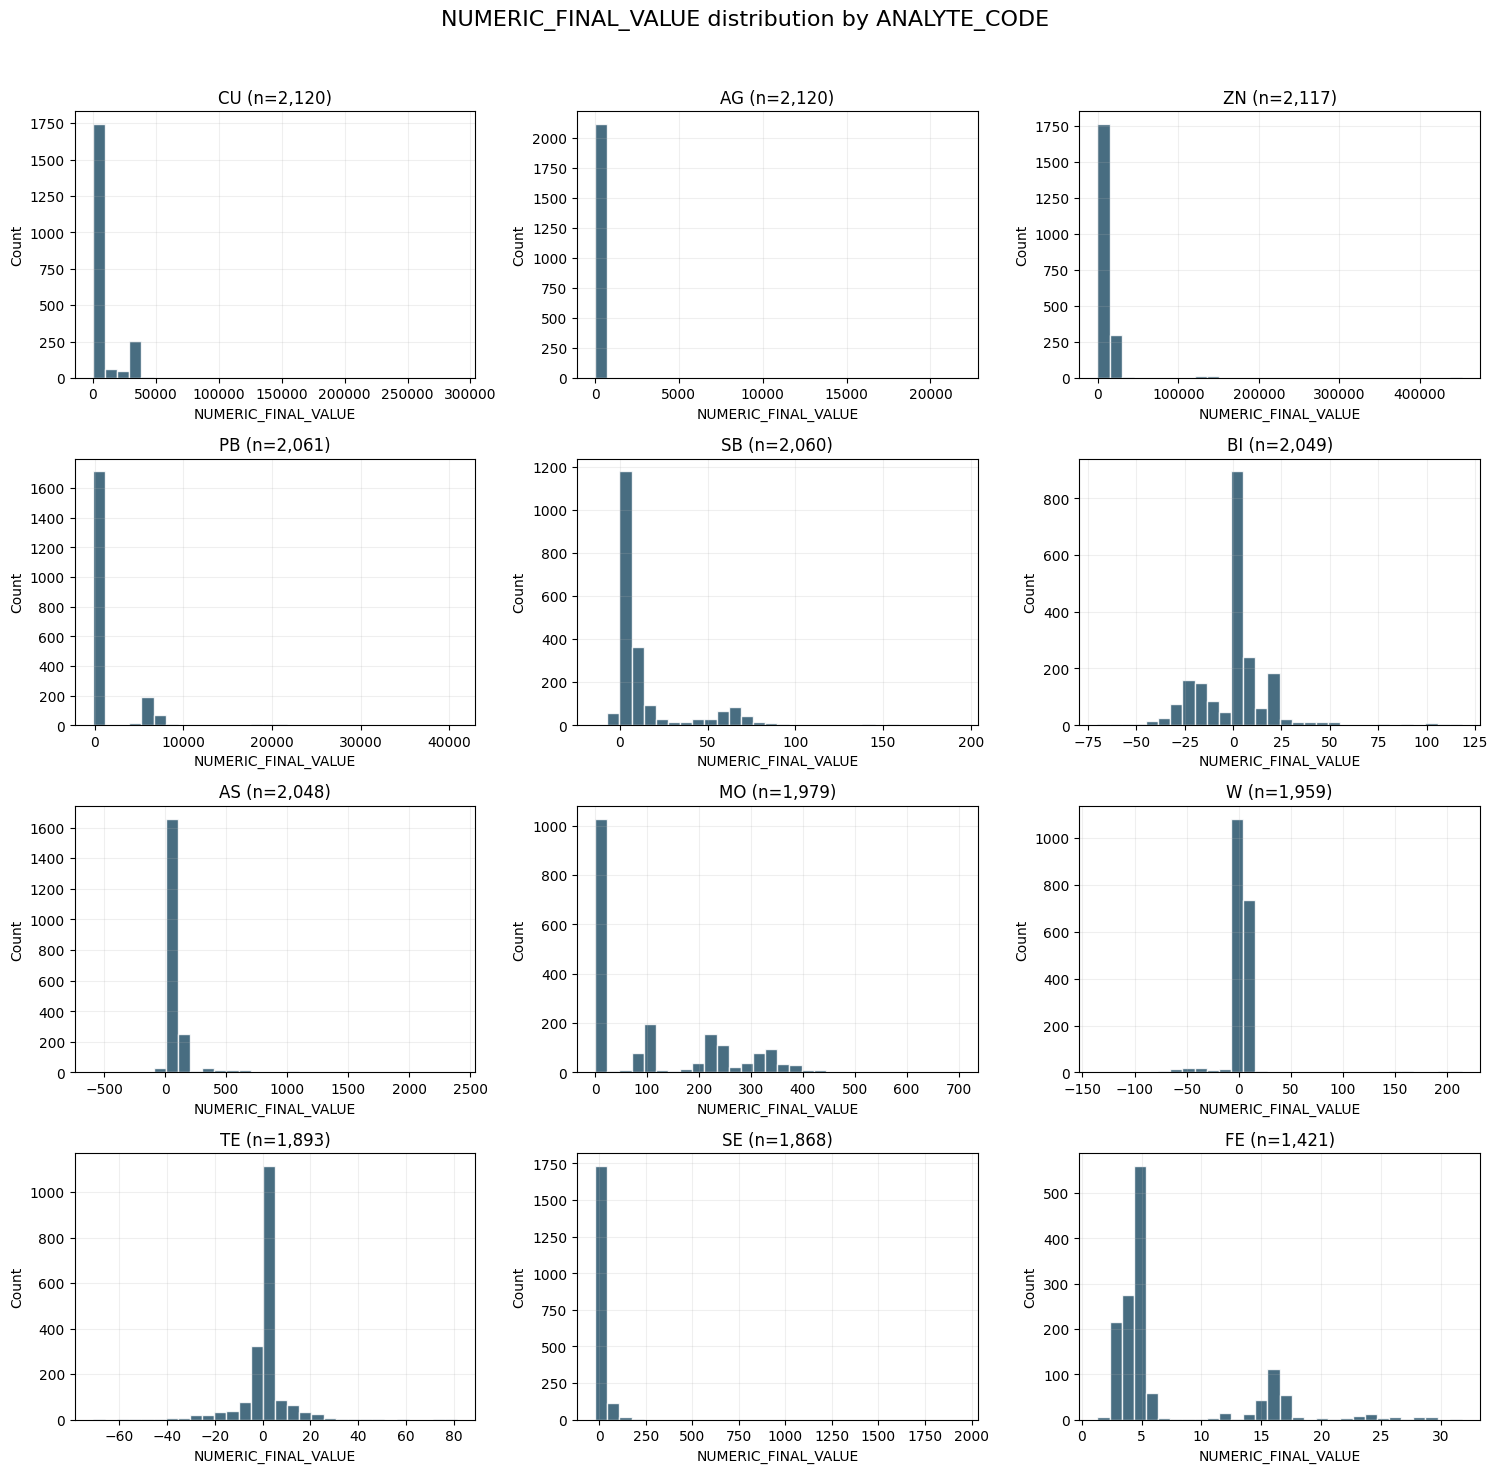

Showing the 12 most frequent analyte codes for readability.


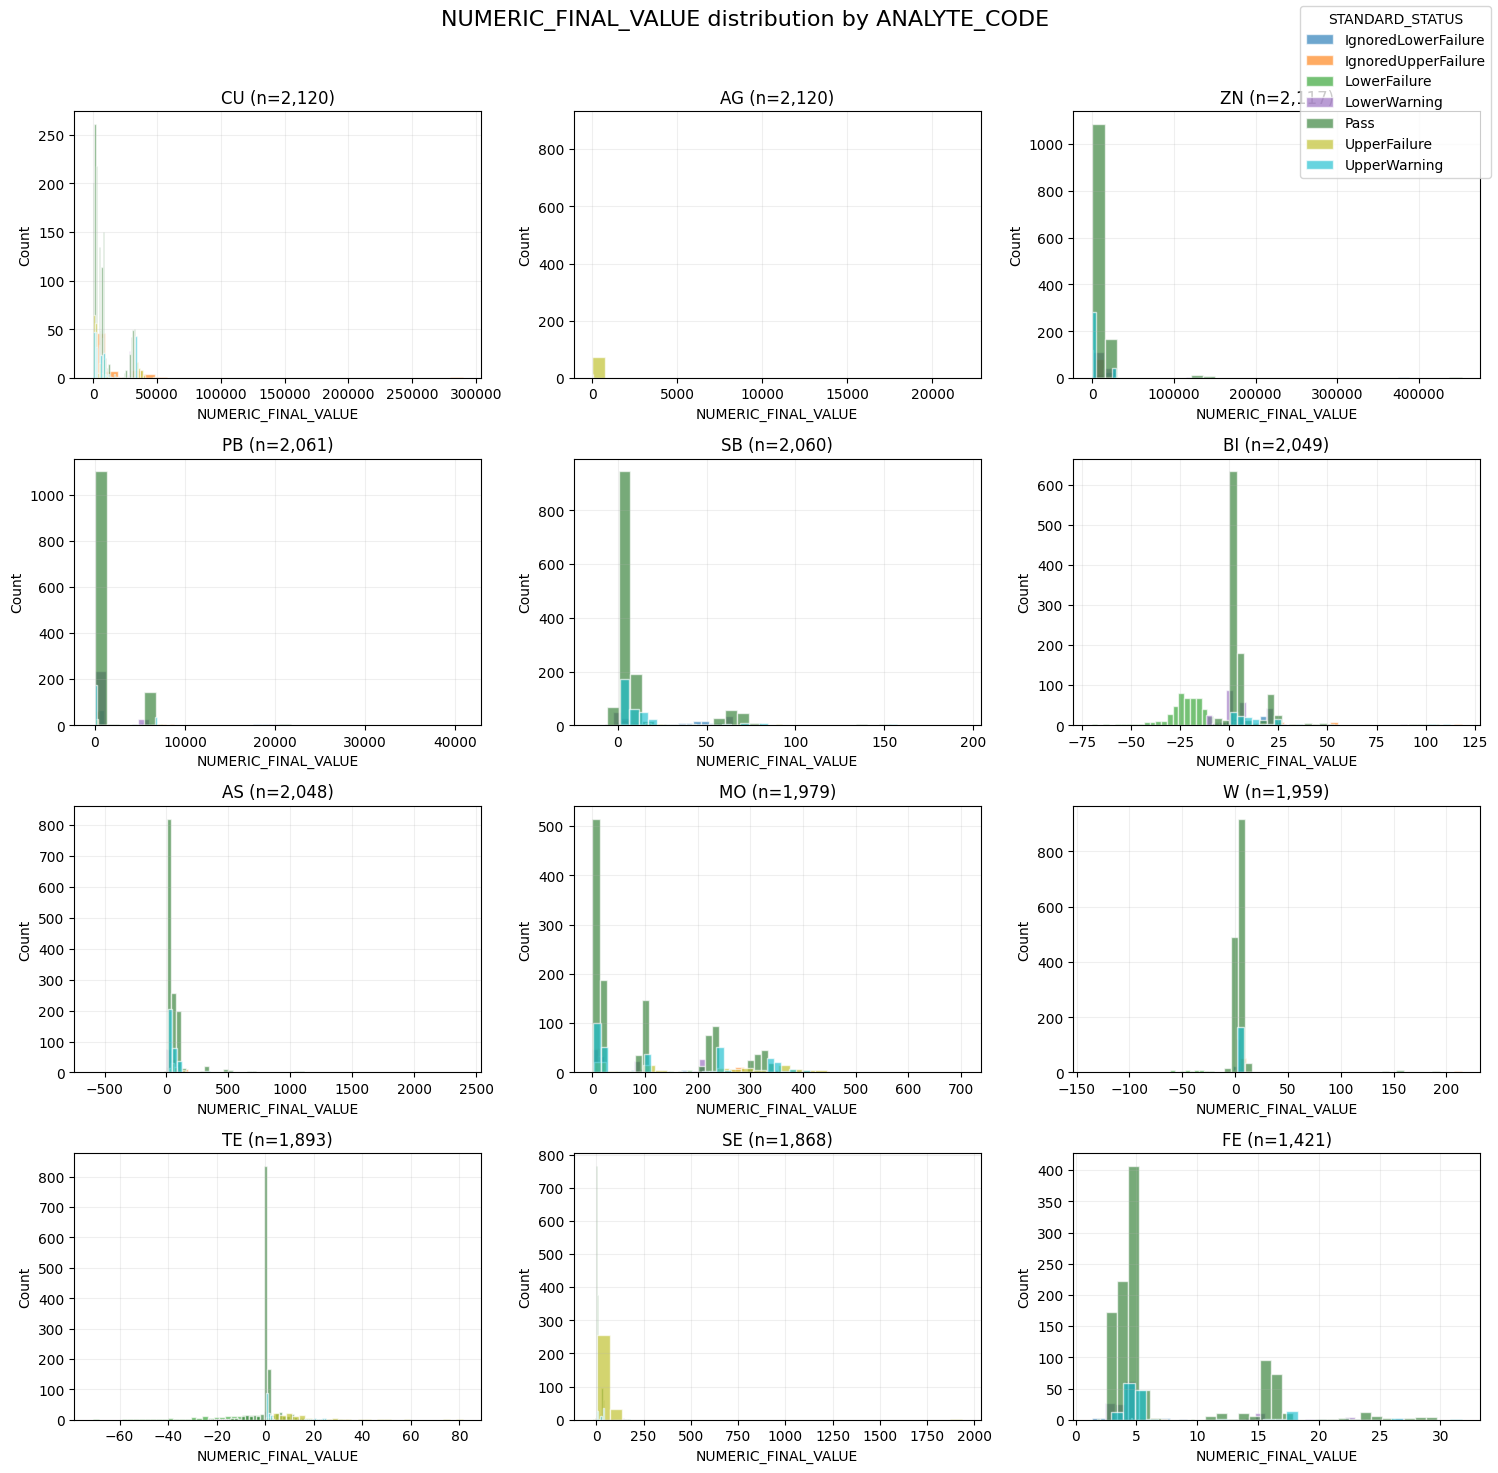

Showing the 12 most frequent analyte codes for readability.


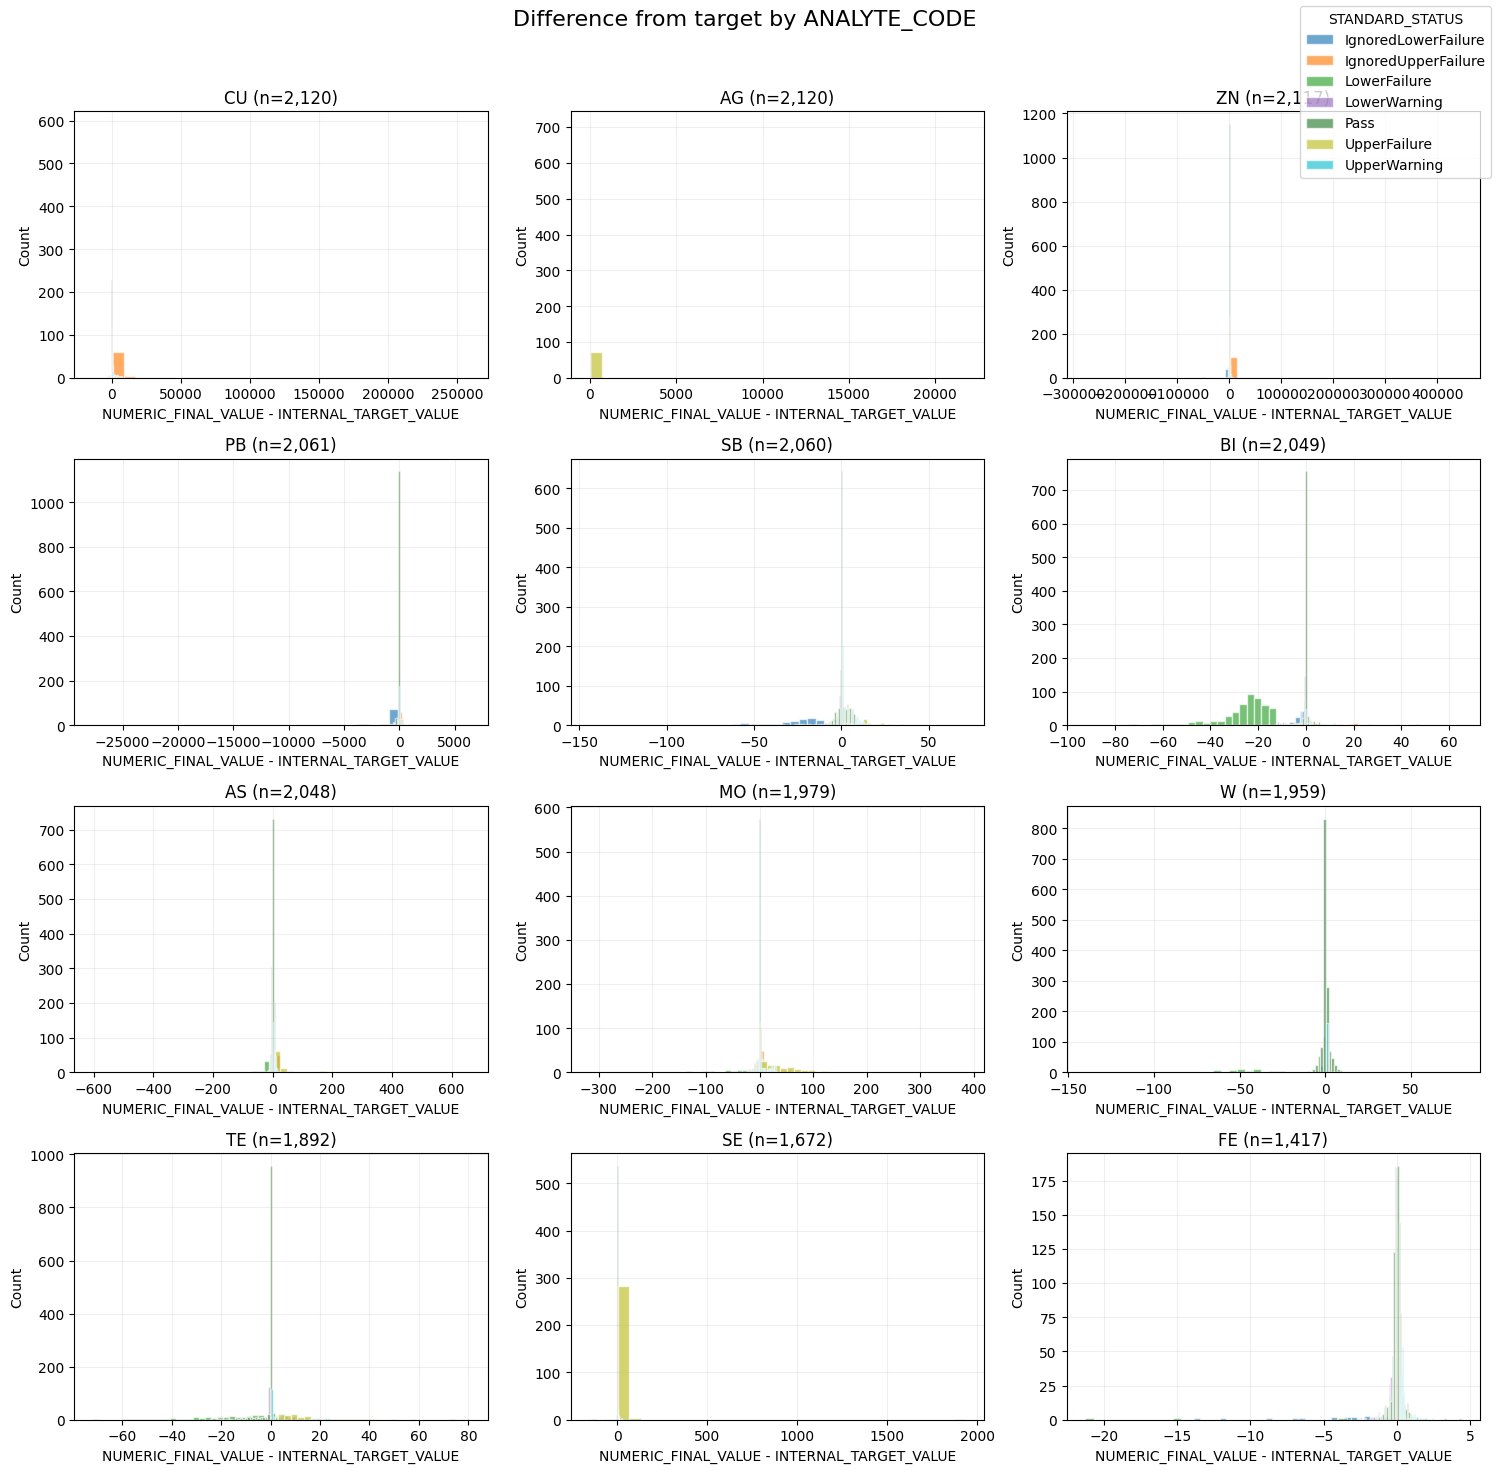

In [6]:
MAX_ANALYTES_TO_PLOT = 12


def plot_histograms_by_analyte(data, value_col, title, xlabel, max_analytes=MAX_ANALYTES_TO_PLOT):
    plot_data = data.dropna(subset=["ANALYTE_CODE", value_col]).copy()
    analytes = plot_data["ANALYTE_CODE"].value_counts().head(max_analytes).index.tolist()
    if not analytes:
        print(f"No data available for {value_col}.")
        return

    if plot_data["ANALYTE_CODE"].nunique() > max_analytes:
        print(f"Showing the {max_analytes} most frequent analyte codes for readability.")

    ncols = 3
    nrows = int(np.ceil(len(analytes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, analyte in zip(axes, analytes):
        values = plot_data.loc[plot_data["ANALYTE_CODE"] == analyte, value_col]
        ax.hist(values, bins=30, color="#28536B", edgecolor="white", alpha=0.85)
        ax.set_title(f"{analyte} (n={len(values):,})")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.grid(alpha=0.2)

    for ax in axes[len(analytes):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


plot_histograms_by_analyte(
    standard_analyte_df,
    value_col="NUMERIC_FINAL_VALUE",
    title="NUMERIC_FINAL_VALUE distribution by ANALYTE_CODE",
    xlabel="NUMERIC_FINAL_VALUE",
)

MAX_ANALYTES_TO_PLOT = 12


def plot_histograms_by_analyte(data, value_col, title, xlabel, max_analytes=MAX_ANALYTES_TO_PLOT):
    plot_data = data.dropna(subset=["ANALYTE_CODE", value_col]).copy()
    analytes = plot_data["ANALYTE_CODE"].value_counts().head(max_analytes).index.tolist()
    if not analytes:
        print(f"No data available for {value_col}.")
        return

    if plot_data["ANALYTE_CODE"].nunique() > max_analytes:
        print(f"Showing the {max_analytes} most frequent analyte codes for readability.")

    ncols = 3
    nrows = int(np.ceil(len(analytes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
    axes = np.array(axes).reshape(-1)

    if "STANDARD_STATUS" in plot_data.columns:
        plot_data["STANDARD_STATUS"] = plot_data["STANDARD_STATUS"].fillna("Unknown").astype(str)
        statuses = sorted(plot_data["STANDARD_STATUS"].unique())

        status_palette = {
            "Pass": "#2E7D32",
            "Fail": "#C62828",
            "Warning": "#EF6C00",
            "Unknown": "#6D6D6D",
        }
        fallback_colors = plt.cm.tab10(np.linspace(0, 1, max(len(statuses), 1)))
        status_colors = {
            status: status_palette.get(status, fallback_colors[i % len(fallback_colors)])
            for i, status in enumerate(statuses)
        }

        for ax, analyte in zip(axes, analytes):
            analyte_data = plot_data[plot_data["ANALYTE_CODE"] == analyte]
            for status in statuses:
                values = analyte_data.loc[analyte_data["STANDARD_STATUS"] == status, value_col]
                if values.empty:
                    continue
                ax.hist(
                    values,
                    bins=30,
                    color=status_colors[status],
                    alpha=0.65,
                    edgecolor="white",
                    label=status,
                )
            ax.set_title(f"{analyte} (n={len(analyte_data):,})")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Count")
            ax.grid(alpha=0.2)

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, title="STANDARD_STATUS", loc="upper right")
    else:
        for ax, analyte in zip(axes, analytes):
            values = plot_data.loc[plot_data["ANALYTE_CODE"] == analyte, value_col]
            ax.hist(values, bins=30, color="#28536B", edgecolor="white", alpha=0.85)
            ax.set_title(f"{analyte} (n={len(values):,})")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Count")
            ax.grid(alpha=0.2)

    for ax in axes[len(analytes):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


plot_histograms_by_analyte(
    standard_analyte_df,
    value_col="NUMERIC_FINAL_VALUE",
    title="NUMERIC_FINAL_VALUE distribution by ANALYTE_CODE",
    xlabel="NUMERIC_FINAL_VALUE",
)

plot_histograms_by_analyte(
    standard_analyte_df,
    value_col="TARGET_DIFFERENCE",
    title="Difference from target by ANALYTE_CODE",
    xlabel="NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE",
)

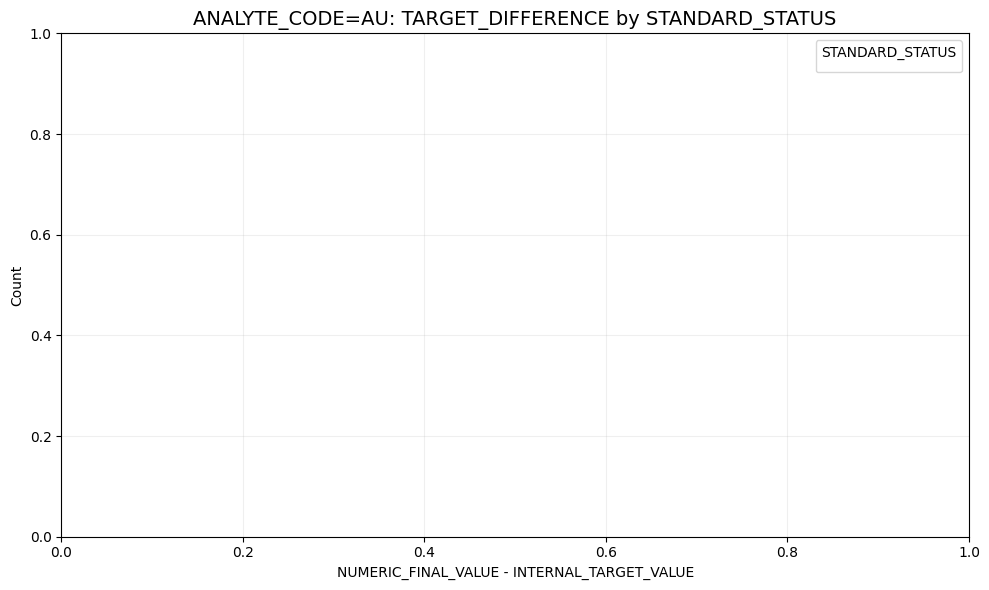

In [7]:
import plotly.express as px
plot_data = standard_analyte_df[
    (standard_analyte_df["ANALYTE_CODE"] == "AU") &
    standard_analyte_df["TARGET_DIFFERENCE"].notna()
].copy()

plot_data["STANDARD_STATUS"] = plot_data["STANDARD_STATUS"].fillna("Unknown").astype(str)

fig = px.histogram(
    plot_data,
    x="TARGET_DIFFERENCE",
    color="STANDARD_STATUS",
    nbins=30,
    #color_discrete_map=status_colors,
    title="ANALYTE_CODE=AU: TARGET_DIFFERENCE by STANDARD_STATUS",
    labels={"TARGET_DIFFERENCE": "NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE"},
    hover_data={"STANDARD_STATUS": True},
)

fig.update_layout(
    xaxis_title="NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE",
    yaxis_title="Count",
    legend_title="STANDARD_STATUS",
    hovermode="closest",
)
fig.show()

status_palette = {
    "Pass": "#2E7D32",
    "Fail": "#C62828",
    "Warning": "#EF6C00",
    "Unknown": "#6D6D6D",
}
statuses = sorted(plot_data["STANDARD_STATUS"].unique())
fallback_colors = plt.cm.tab10(np.linspace(0, 1, max(len(statuses), 1)))
status_colors = {
    status: status_palette.get(status, fallback_colors[i % len(fallback_colors)])
    for i, status in enumerate(statuses)
}

fig, ax = plt.subplots(figsize=(10, 6))

for status in statuses:
    values = plot_data.loc[plot_data["STANDARD_STATUS"] == status, "TARGET_DIFFERENCE"]
    if not values.empty:
        ax.hist(
            values,
            bins=100,
            color=status_colors[status],
            alpha=0.65,
            edgecolor="white",
            label=status,
        )

ax.set_title("ANALYTE_CODE=AU: TARGET_DIFFERENCE by STANDARD_STATUS", fontsize=14)
ax.set_xlabel("NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE")
ax.set_ylabel("Count")
ax.legend(title="STANDARD_STATUS")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
standard_analyte_df.head(10)

,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,INTERNAL_MAX_INCLUSIVE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID,JOB_NAME_ANON,ANALYTICAL_TYPE_CLEAN,TARGET_DIFFERENCE
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,26.110560,34.689440,Y,Y,33.120800,27.679200,Y,Y,10,1.25,15.0,1.25,30.400,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,5.527171
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,26.110560,34.689440,Y,Y,33.120800,27.679200,Y,Y,10,1.25,15.0,1.25,30.400,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,25.239610
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,7.336260,11.743740,Y,Y,10.937610,8.142390,Y,Y,10,5.00,15.0,5.00,9.540,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,2.202601
5,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,12.236060,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperFailure,NaN,7.336260,11.743740,Y,Y,10.937610,8.142390,Y,Y,10,5.00,15.0,5.00,9.540,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,2.696060
7,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,1501.882410,2021-11-22 16:35:49.000000,GE_IMS40Q12,CU,Pass,NaN,1379.700000,1686.300000,Y,Y,1630.192200,1435.807800,Y,Y,10,5.00,15.0,5.00,1533.000,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,-31.117590
8,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,1550.868306,2021-11-22 16:35:49.000000,GE_IMS40Q12,CU,Pass,NaN,1379.700000,1686.300000,Y,Y,1630.192200,1435.807800,Y,Y,10,5.00,15.0,5.00,1533.000,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,17.868306
10,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,1.093424,2021-11-22 16:35:49.000000,GE_IMS40Q12,AG,IgnoredUpperFailure,NaN,0.416213,0.619787,Y,Y,0.582543,0.453457,Y,Y,10,0.05,15.0,0.05,0.518,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,0.575424
11,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,162.756679,2021-11-22 16:35:49.000000,GE_IMS40Q12,ZN,IgnoredUpperFailure,NaN,124.144800,151.855200,Y,Y,146.790600,129.209400,Y,Y,10,12.50,15.0,12.50,138.000,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,24.756679
12,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,0.705665,2021-11-22 16:35:49.000000,GE_IMS40Q12,AG,UpperFailure,NaN,0.416213,0.619787,Y,Y,0.582543,0.453457,Y,Y,10,0.05,15.0,0.05,0.518,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,0.187665
13,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,143.443845,2021-11-22 16:35:49.000000,GE_IMS40Q12,ZN,Pass,NaN,124.144800,151.855200,Y,Y,146.790600,129.209400,Y,Y,10,12.50,15.0,12.50,138.000,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,5.443845


In [14]:
standard_analyte_df['STD_CODE'].value_counts(dropna=False)
#JOB_CODE

STD_CODE
OREAS_502C    6872
OREAS_905     5639
OREAS_62F     5509
OREAS_501C    5368
OREAS_624     4285
OREAS_503C    4271
OREAS_522     1089
OREAS_139      982
OREAS_908      714
OREAS_524      501
OREAS_503D     225
OREAS_351      205
OREAS_20A      161
OREAS_98       157
OREAS_623      131
OREAS_621       60
OREAS_505       57
OREAS_520       26
OREAS_136       24
OREAS_38        21
OREAS_45F       10
OREAS_45H       10
OREAS_622       10
OREAS_605        6
Name: count, dtype: int64

In [12]:
standard_analyte_df['STD_LOT_CODE'].value_counts(dropna=False)

STD_LOT_CODE
Sample        6872
OREAS_905     5639
OREAS_62F     5509
OREAS_501C    5368
OREAS_624     4285
OREAS_503C    4271
OREAS_522     1089
OREAS_139      982
OREAS_908      714
OREAS_524      501
OREAS_503D     225
OREAS_351      205
OREAS_20A      161
OREAS_98       157
OREAS_623      131
OREAS_621       60
OREAS_505       57
OREAS_520       26
OREAS_136       24
OREAS_38        21
OREAS_45F       10
OREAS_45H       10
OREAS_622       10
OREAS_605        6
Name: count, dtype: int64

In [29]:
standard_analyte_df[standard_analyte_df['STD_LOT_CODE']=='OREAS_905']['JOB_CODE'].value_counts(dropna=False)

JOB_CODE
TSV_LB0005394796    170
TSV_LB0005186285    170
TSV_LB0005186144    170
TSV_LB0004988884    170
TSV_LB0006066326    168
                   ... 
TSV_LB0004622664      1
TSV_LB0004521920      1
TSV_LB0003617921      1
TSV_LB0003291263      1
TSV_LB0003119185      1
Name: count, Length: 203, dtype: int64

Showing the 12 most frequent analyte codes for readability.


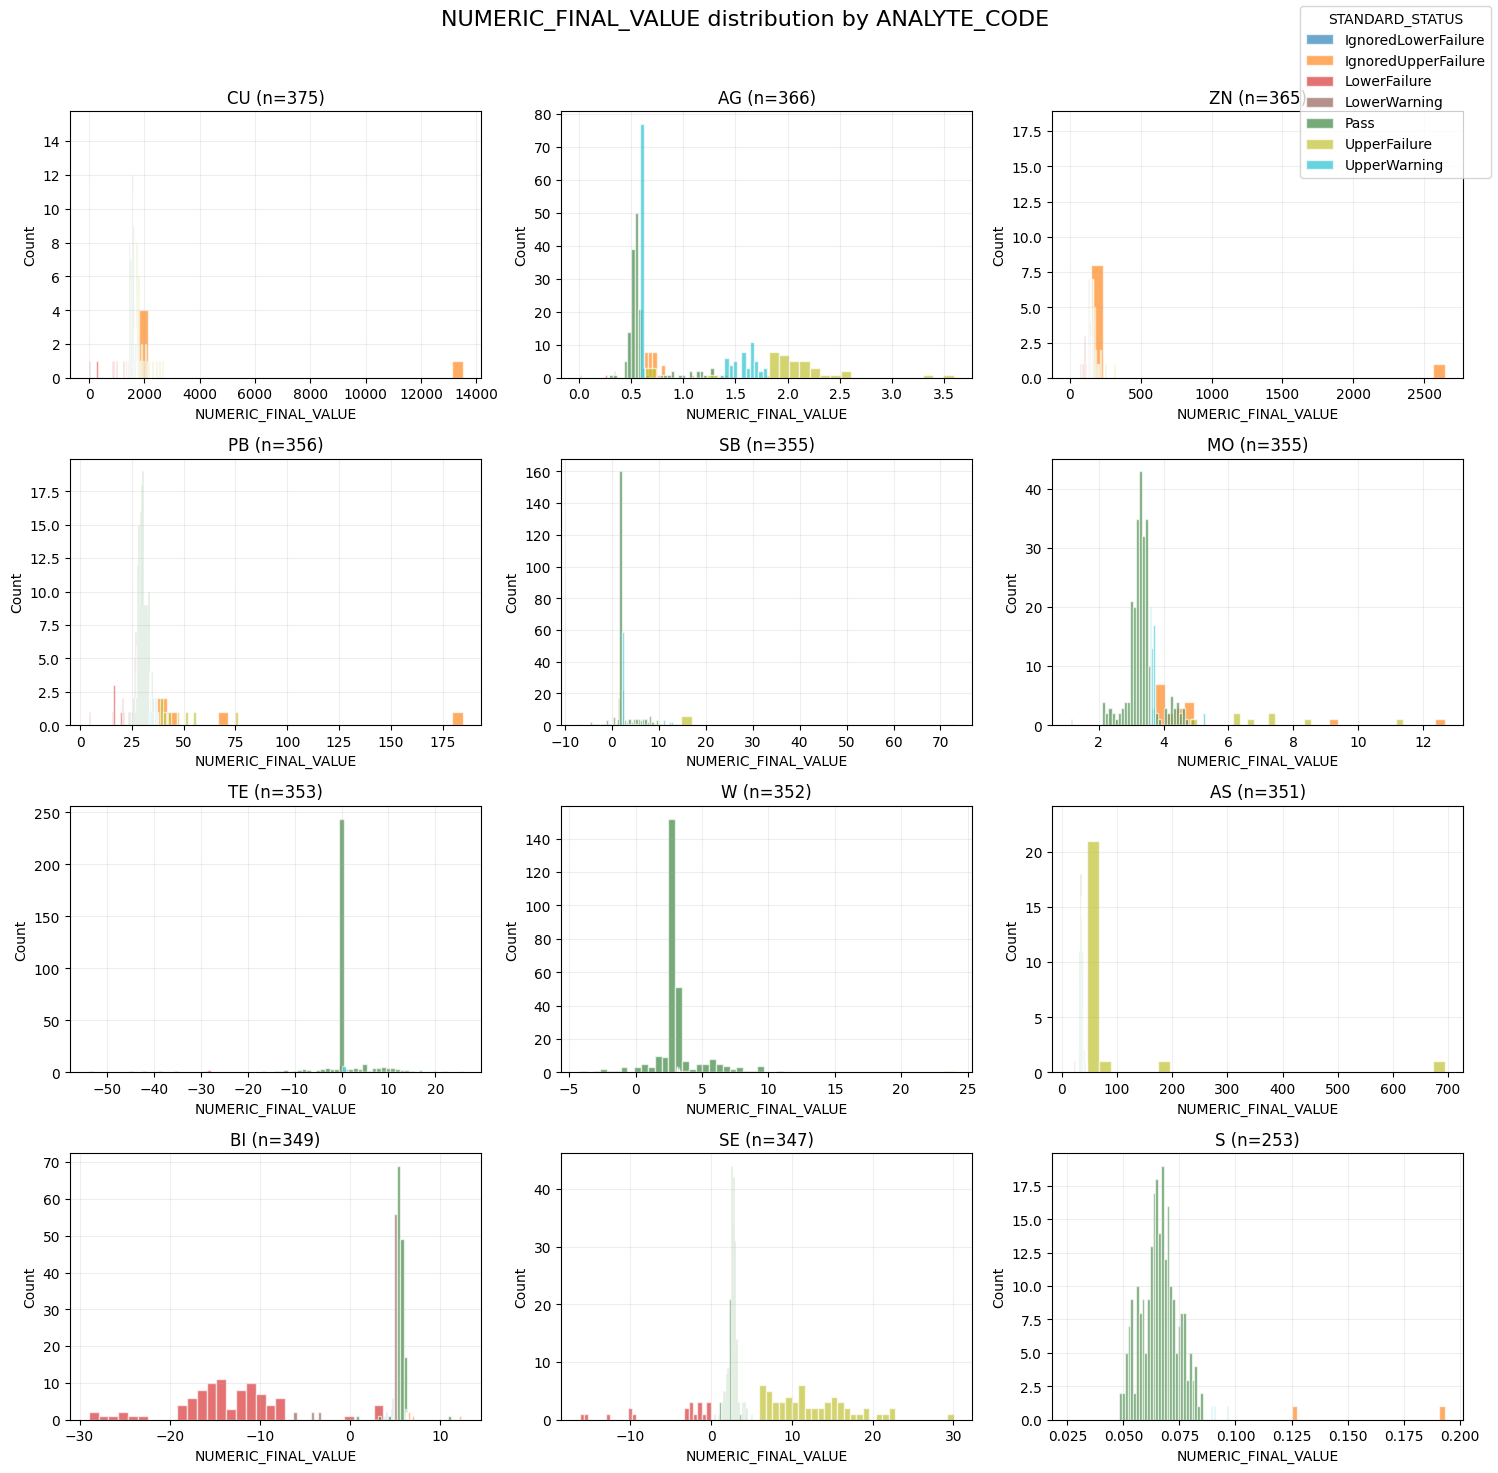

In [27]:
plot_histograms_by_analyte(
    standard_analyte_df[standard_analyte_df['STD_LOT_CODE']=='OREAS_905'],
    value_col="NUMERIC_FINAL_VALUE",
    title="NUMERIC_FINAL_VALUE distribution by ANALYTE_CODE",
    xlabel="NUMERIC_FINAL_VALUE",
)

In [34]:
standard_analyte_df[(standard_analyte_df['STD_LOT_CODE']=='OREAS_905') | (standard_analyte_df['STD_LOT_CODE'] == 'TSV_LB0004988884')].head(5)

,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,INTERNAL_MAX_INCLUSIVE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID,JOB_NAME_ANON,ANALYTICAL_TYPE_CLEAN,TARGET_DIFFERENCE
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,26.11056,34.68944,Y,Y,33.12080,27.67920,Y,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,5.527171
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,26.11056,34.68944,Y,Y,33.12080,27.67920,Y,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,25.239610
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,7.33626,11.74374,Y,Y,10.93761,8.14239,Y,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,2.202601
5,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,12.236060,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperFailure,NaN,7.33626,11.74374,Y,Y,10.93761,8.14239,Y,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,2.696060
7,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,1501.882410,2021-11-22 16:35:49.000000,GE_IMS40Q12,CU,Pass,NaN,1379.70000,1686.30000,Y,Y,1630.19220,1435.80780,Y,Y,10,5.00,15.0,5.00,1533.00,NaN,MG_KG,OREAS_905,NaN,NaN,Standard,-31.117590


Showing the 12 most frequent analyte codes for readability.


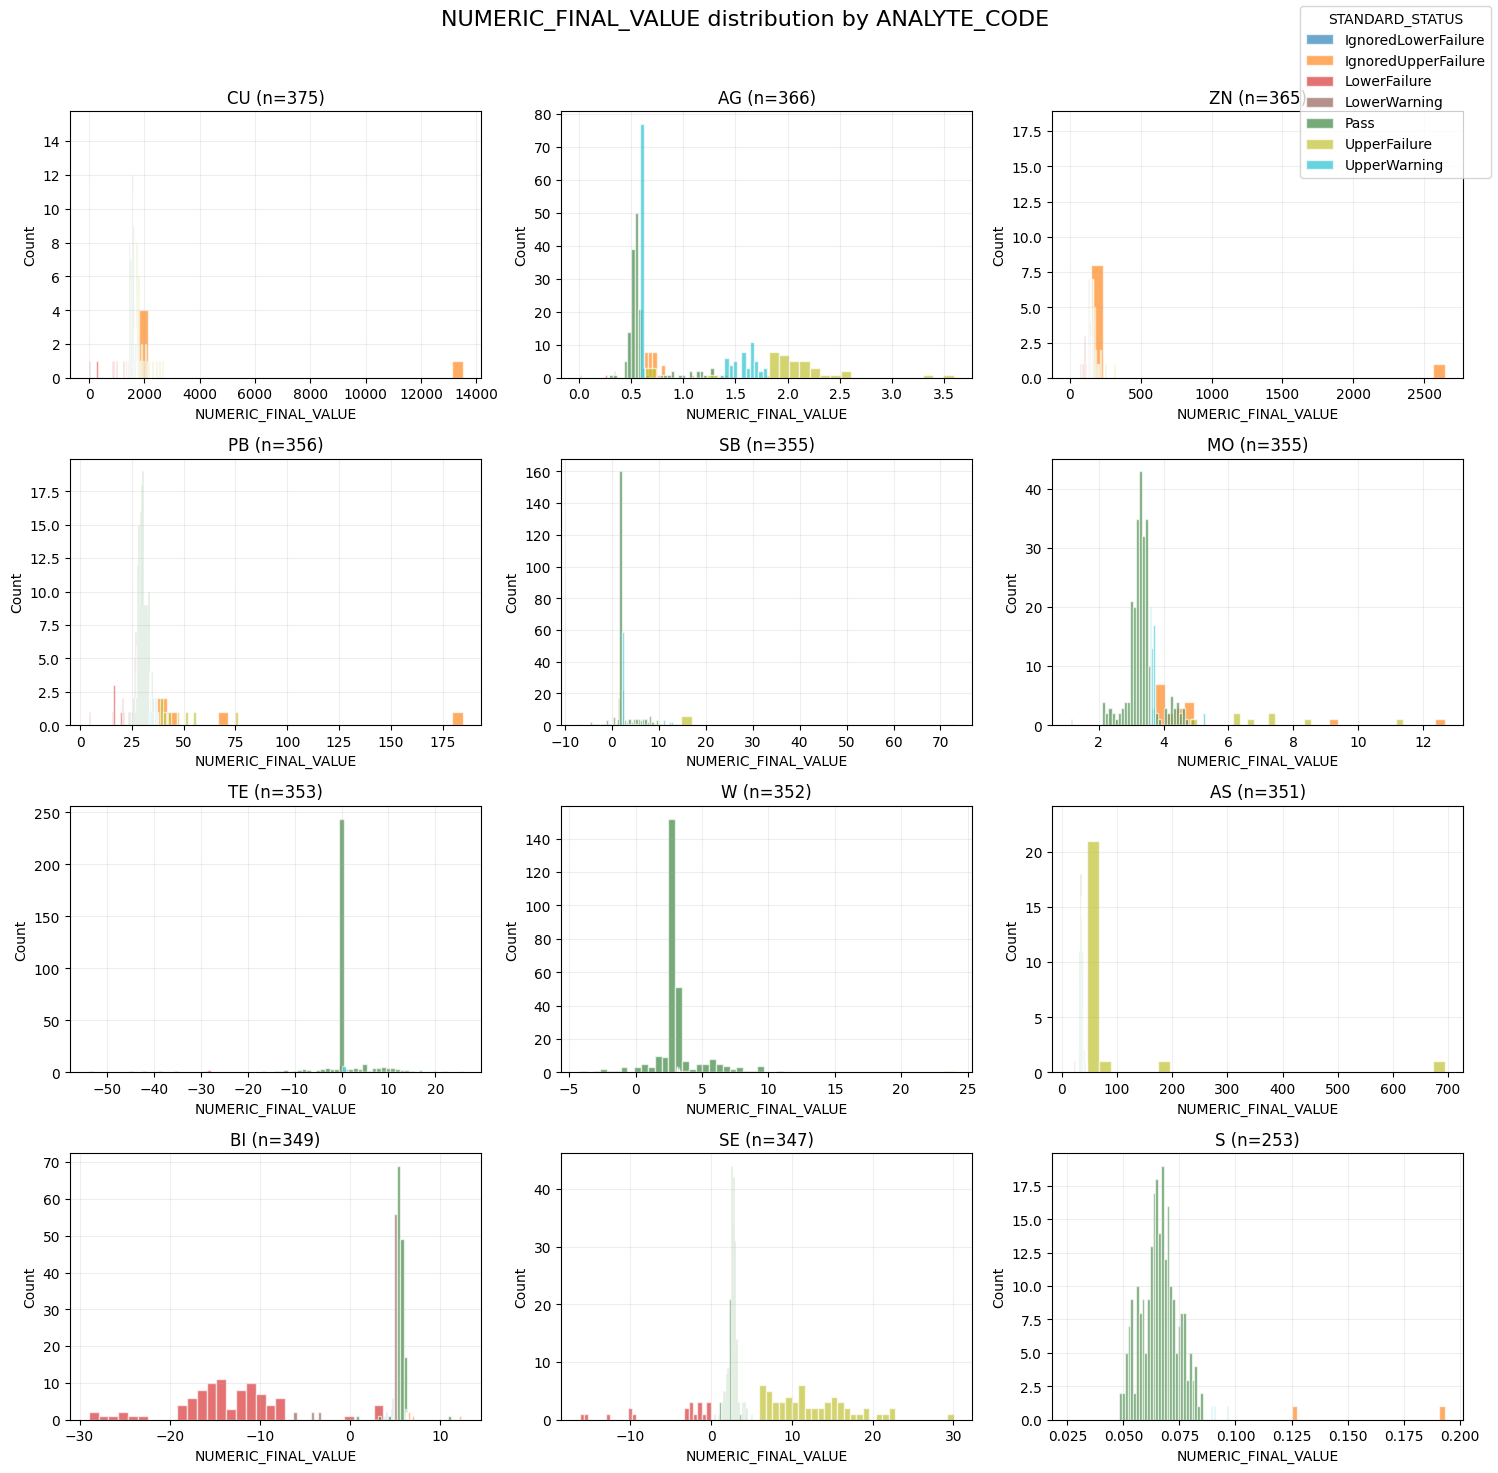

In [32]:
plot_histograms_by_analyte(
    standard_analyte_df[(standard_analyte_df['STD_LOT_CODE']=='OREAS_905') | (standard_analyte_df['STD_LOT_CODE'] == 'TSV_LB0004988884')],
    value_col="NUMERIC_FINAL_VALUE",
    title="NUMERIC_FINAL_VALUE distribution by ANALYTE_CODE",
    xlabel="NUMERIC_FINAL_VALUE",
)

In [36]:
standard_analyte_df['STANDARD_STATUS'].value_counts(dropna=False)

STANDARD_STATUS
Pass                   24291
UpperWarning            3907
LowerWarning            2894
LowerFailure            1569
UpperFailure            1382
IgnoredLowerFailure     1146
IgnoredUpperFailure     1139
NaN                        5
Name: count, dtype: int64